# Oct 2024 monitoring

In [1]:
%load_ext jupyter_black
%load_ext autoreload
%autoreload 2

In [24]:
import os
from pathlib import Path

import pandas as pd
import xarray as xr

from ochanticipy import (
    create_country_config,
    CodAB,
    GeoBoundingBox,
)

from src.download_cmorph_new import download_historical_spi
from src.process_spi import process_spi

In [26]:
NEW_CMORPH_DIR = Path(os.environ["NEW_CMORPH_DIR"])
AA_DATA_DIR = Path(os.environ["AA_DATA_DIR"])
SPI_PROC_DIR = AA_DATA_DIR / "public/processed/bfa/cmorph_spi/new"

In [15]:
iso3 = "bfa"
adm_sel = ["Boucle du Mouhoun", "Nord", "Centre-Nord", "Sahel"]

country_config = create_country_config(iso3=iso3)
codab = CodAB(country_config=country_config)
gdf_adm1 = codab.load(admin_level=1)
gdf_aoi = gdf_adm1[gdf_adm1["ADM1_FR"].isin(adm_sel)]

<Axes: >

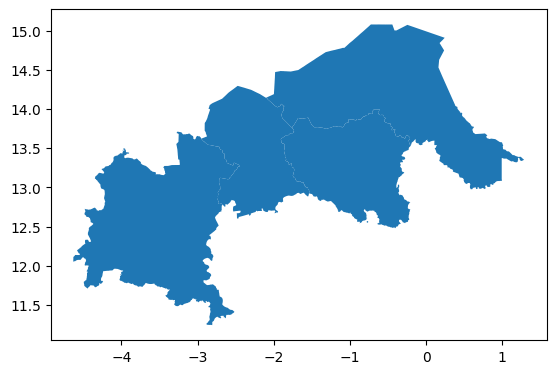

In [17]:
gdf_aoi.plot()

In [18]:
dates = pd.date_range("2024-09-01", "2024-10-01")

In [46]:
for date in dates:
    download_historical_spi(str(date.date()))

Downloaded to /Users/tdowning/OCHA/data/GLOBAL/new_cmorph/GLOBAL-NOAA_CPC_CMORPH-spi-1mo_2024-09-01.tif
Downloaded to /Users/tdowning/OCHA/data/GLOBAL/new_cmorph/GLOBAL-NOAA_CPC_CMORPH-spi-1mo_2024-09-02.tif
Downloaded to /Users/tdowning/OCHA/data/GLOBAL/new_cmorph/GLOBAL-NOAA_CPC_CMORPH-spi-1mo_2024-09-03.tif
Downloaded to /Users/tdowning/OCHA/data/GLOBAL/new_cmorph/GLOBAL-NOAA_CPC_CMORPH-spi-1mo_2024-09-04.tif
Downloaded to /Users/tdowning/OCHA/data/GLOBAL/new_cmorph/GLOBAL-NOAA_CPC_CMORPH-spi-1mo_2024-09-05.tif
Downloaded to /Users/tdowning/OCHA/data/GLOBAL/new_cmorph/GLOBAL-NOAA_CPC_CMORPH-spi-1mo_2024-09-06.tif
Downloaded to /Users/tdowning/OCHA/data/GLOBAL/new_cmorph/GLOBAL-NOAA_CPC_CMORPH-spi-1mo_2024-09-07.tif
Downloaded to /Users/tdowning/OCHA/data/GLOBAL/new_cmorph/GLOBAL-NOAA_CPC_CMORPH-spi-1mo_2024-09-08.tif
Downloaded to /Users/tdowning/OCHA/data/GLOBAL/new_cmorph/GLOBAL-NOAA_CPC_CMORPH-spi-1mo_2024-09-09.tif
Downloaded to /Users/tdowning/OCHA/data/GLOBAL/new_cmorph/GLOBAL

In [47]:
process_spi(verbose=True)

GLOBAL-NOAA_CPC_CMORPH-spi-1mo_2024-09-18.tif
<xarray.DataArray (band: 1, y: 480, x: 1440)>
[691200 values with dtype=float64]
Coordinates:
  * band         (band) int64 1
  * x            (x) float64 -179.9 -179.6 -179.4 -179.1 ... 179.4 179.6 179.9
  * y            (y) float64 59.88 59.62 59.38 59.12 ... -59.38 -59.62 -59.88
    spatial_ref  int64 0
Attributes:
    AREA_OR_POINT:  Area
    scale_factor:   1.0
    add_offset:     0.0
    long_name:      spi
GLOBAL-NOAA_CPC_CMORPH-spi-1mo_2024-09-24.tif
<xarray.DataArray (band: 1, y: 480, x: 1440)>
[691200 values with dtype=float64]
Coordinates:
  * band         (band) int64 1
  * x            (x) float64 -179.9 -179.6 -179.4 -179.1 ... 179.4 179.6 179.9
  * y            (y) float64 59.88 59.62 59.38 59.12 ... -59.38 -59.62 -59.88
    spatial_ref  int64 0
Attributes:
    AREA_OR_POINT:  Area
    scale_factor:   1.0
    add_offset:     0.0
    long_name:      spi
GLOBAL-NOAA_CPC_CMORPH-spi-1mo_2024-09-25.tif
<xarray.DataArray (band: 1, 

In [48]:
f"{dates[0].date()}"

'2024-09-01'

In [52]:
verbose = False
das = []
for date in dates:
    filename = f"bfa-spi1-{date.date()}.nc"
    try:
        da_in = xr.open_dataset(SPI_PROC_DIR / filename)["spi_1"]
    except Exception as e:
        if verbose:
            print(e)
        continue
    das.append(da_in)

da = xr.concat(das, dim="date")

In [53]:
da.mean(dim=["x", "y"])

<xarray.DataArray 'spi_1' (date: 23)>
array([0.81962411, 0.76801032, 0.80874156, 0.8680001 , 0.75713699,
       0.72742024, 0.87707705, 0.97005917, 0.95732271, 0.94902196,
       1.10251958, 1.04436795, 0.99815082, 1.0081194 , 1.17895849,
       1.21931889, 1.16504302, 1.20866649, 1.34639905, 1.07523673,
       1.02638203, 0.77194263, 0.92400832])
Coordinates:
  * date     (date) datetime64[ns] 2024-09-01 2024-09-02 ... 2024-09-25

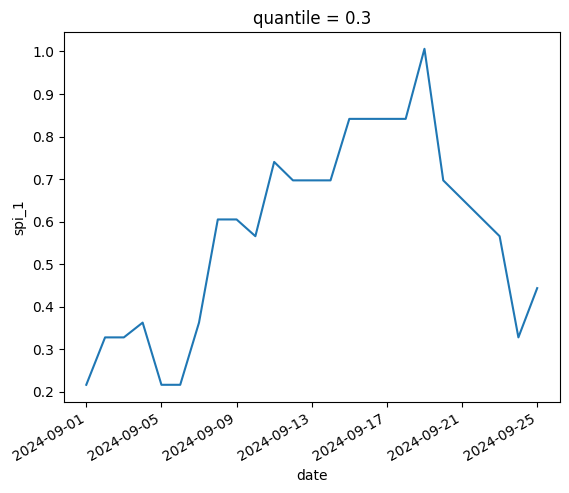

In [55]:
da.quantile(0.3, dim=["x", "y"]).plot()